<a href="https://colab.research.google.com/github/mikhail-mat/mit-ocw_hands-on-deep-learning/blob/main/GloVe_Standalone_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras

keras.utils.set_random_seed(42)

In [2]:
# stole these straight out of the course ipynb

def plot_loss_curves(history):
    plt.clf()
    history_dict = history.history
    loss_values = history_dict["loss"]
    val_loss_values = history_dict["val_loss"]
    epochs = range(1, len(loss_values) + 1)
    plt.plot(epochs, loss_values, "bo", label="Training loss")
    plt.plot(epochs, val_loss_values, "b", label="Validation loss")
    plt.title("Training and validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

def plot_acc_curves(history):
    plt.clf()
    history_dict = history.history
    acc = history_dict["accuracy"]
    val_acc = history_dict["val_accuracy"]
    epochs = range(1, len(acc) + 1)
    plt.plot(epochs, acc, "bo", label="Training acc")
    plt.plot(epochs, val_acc, "b", label="Validation acc")
    plt.title("Training and validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

In [3]:
train_url = "https://www.dropbox.com/scl/fi/ito6bnl2yaf1uw0uqibzf/lyric_genre_train.csv?rlkey=04dkn5un2djza8x0bdmfnlw3u&st=y47qh8i4&dl=1"
val_url = "https://www.dropbox.com/scl/fi/xmywjzqsaa8n5sn1bs0t9/lyric_genre_val.csv?rlkey=hggbeo0s1iaxjpa6z80429xl9&st=6i7d8eau&dl=1"
test_url = "https://www.dropbox.com/scl/fi/fnocl69w9ojs9s5zb0xvf/lyric_genre_test.csv?rlkey=z4hjopw7vaihoh948cbb5mvdp&st=xwond7dp&dl=1"

train_df = pd.read_csv(train_url,index_col=0)
val_df = pd.read_csv(val_url,index_col=0)
test_df = pd.read_csv(test_url,index_col=0)

In [4]:
train_df.head()

,Lyric,Genre
0,"Oh, girl. I can't get ready (Can't get ready f...",Pop
1,We met on a rainy evening in the summertime. D...,Pop
2,We carried you in our arms. On Independence Da...,Rock
3,I know he loved you. A long time ago. I ain't ...,Pop
4,Paralysis through analysis. Yellow moral uncle...,Rock


In [5]:
y_train = pd.get_dummies(train_df['Genre']).to_numpy(dtype='float32')
y_val = pd.get_dummies(val_df['Genre']).to_numpy(dtype='float32')
y_test = pd.get_dummies(test_df['Genre']).to_numpy(dtype='float32')

In [6]:
y_train[:5]

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.]], dtype=float32)

In [10]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

--2026-03-27 16:34:36--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-27 16:34:36--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-27 16:34:37--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [7]:
!unzip -q glove.6B.zip

replace glove.6B.50d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace glove.6B.100d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace glove.6B.200d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace glove.6B.300d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [8]:
! head -1 /content/glove.6B.100d.txt

the -0.038194 -0.24487 0.72812 -0.39961 0.083172 0.043953 -0.39141 0.3344 -0.57545 0.087459 0.28787 -0.06731 0.30906 -0.26384 -0.13231 -0.20757 0.33395 -0.33848 -0.31743 -0.48336 0.1464 -0.37304 0.34577 0.052041 0.44946 -0.46971 0.02628 -0.54155 -0.15518 -0.14107 -0.039722 0.28277 0.14393 0.23464 -0.31021 0.086173 0.20397 0.52624 0.17164 -0.082378 -0.71787 -0.41531 0.20335 -0.12763 0.41367 0.55187 0.57908 -0.33477 -0.36559 -0.54857 -0.062892 0.26584 0.30205 0.99775 -0.80481 -3.0243 0.01254 -0.36942 2.2167 0.72201 -0.24978 0.92136 0.034514 0.46745 1.1079 -0.19358 -0.074575 0.23353 -0.052062 -0.22044 0.057162 -0.15806 -0.30798 -0.41625 0.37972 0.15006 -0.53212 -0.2055 -1.2526 0.071624 0.70565 0.49744 -0.42063 0.26148 -1.538 -0.30223 -0.073438 -0.28312 0.37104 -0.25217 0.016215 -0.017099 -0.38984 0.87424 -0.72569 -0.51058 -0.52028 -0.1459 0.8278 0.27062


In [9]:
embedding_dim = 100
path_to_glove_file = f"glove.6B.{embedding_dim}d.txt"

embeddings_index = {}
with open(path_to_glove_file) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} word vectors.")

Found 400000 word vectors.


In [10]:
max_tokens = 3000
max_length = 300

vectorization_layer = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_sequence_length=max_length,
    output_mode='int'
)

In [11]:
vectorization_layer.adapt(train_df['Lyric'])

In [13]:
pd.Series(vectorization_layer.get_vocabulary()[:10])

,0
0,
1,[UNK]
2,the
3,you
4,i
5,to
6,and
7,a
8,me
9,it


In [14]:
vectorization_layer(['The supreme ruler. Khan Is King!'])

<tf.Tensor: shape=(1, 300), dtype=int64, numpy=
array([[  2,   1,   1,   1,  19, 538,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
   

In [16]:
X_train = vectorization_layer(train_df['Lyric'])
X_val = vectorization_layer(val_df['Lyric'])
X_test = vectorization_layer(test_df['Lyric'])

In [17]:
vocab = vectorization_layer.get_vocabulary()
word_index = dict(zip(vocab, range(len(vocab))))

embedding_matrix = np.zeros((max_tokens, embedding_dim)) # each row is a 100 long embedding
for word, i in word_index.items():
  if word in embeddings_index:
    embedding_vector = embeddings_index[word]
    embedding_matrix[i] = embedding_vector

In [18]:
embedding_matrix.shape

(3000, 100)

In [19]:
embedding_matrix[:3,:]

array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0. 

In [20]:
embedding_layer = keras.layers.Embedding(
    max_tokens,
    embedding_dim,
    embeddings_initializer=keras.initializers.Constant(embedding_matrix),
    trainable=False,
    mask_zero=True
)

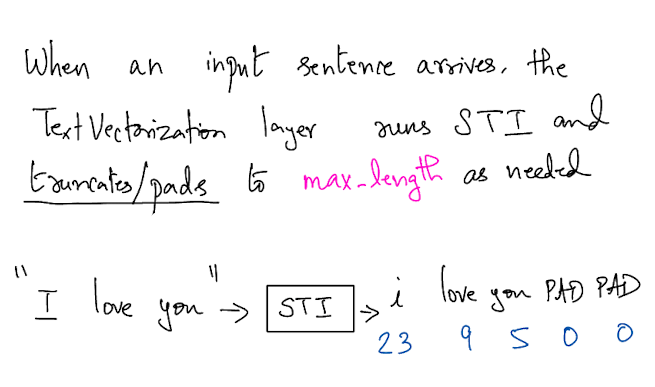

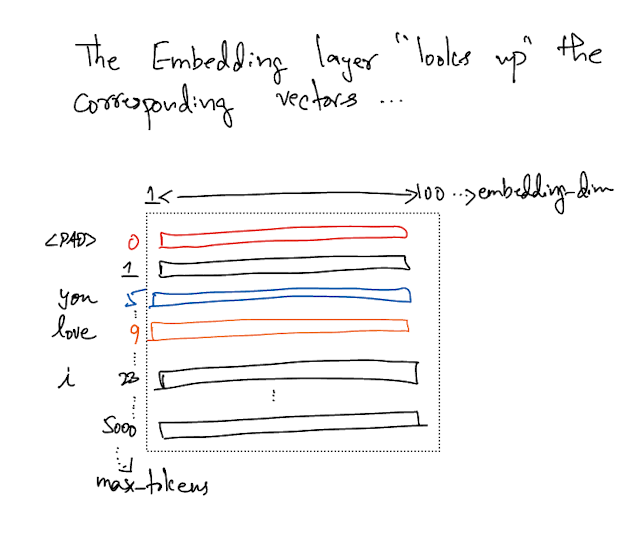

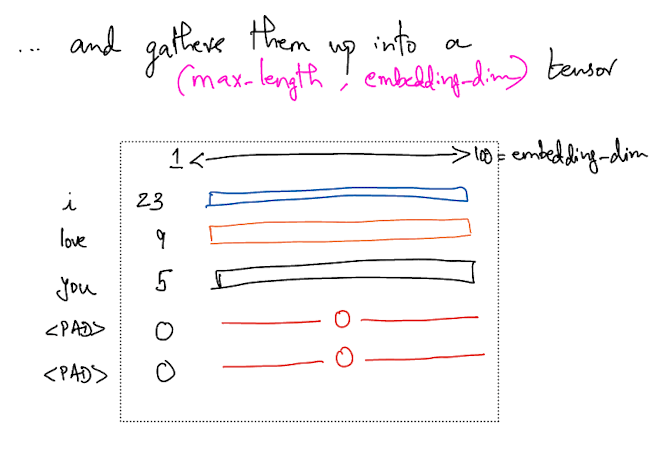

In [30]:
input = keras.layers.Input(shape=(max_length,))
embedded = embedding_layer(input)
embedded = keras.layers.GlobalAveragePooling1D()(embedded)
x = keras.layers.Dense(32, activation='relu')(embedded)
output = keras.layers.Dense(3, activation='softmax')(x)

model = keras.Model(input, output)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 100)  │    300,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 300)       │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ embedding[1][0],  │
│ (GlobalAveragePool… │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      3,232 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │         99 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 303,331 (1.16 MB)

 Trainable params: 3,331 (13.01 KB)

 Non-trainable params: 300,000 (1.14 MB)

In [23]:
model.layers[1].weights

[<Variable path=embedding/embeddings, shape=(3000, 100), dtype=float32, value=[[ 0.        0.        0.       ...  0.        0.        0.      ]
  [ 0.        0.        0.       ...  0.        0.        0.      ]
  [-0.038194 -0.24487   0.72812  ... -0.1459    0.8278    0.27062 ]
  ...
  [ 0.48713   0.6397    1.2523   ... -0.51989  -0.26638   1.0655  ]
  [-0.42196   0.12238   0.43966  ...  0.14452   0.52747   0.90691 ]
  [-0.20221   1.1333   -1.6288   ...  0.11204   0.27214   0.43248 ]]>]

In [31]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [32]:
history = model.fit(X_train,
          y_train,
          batch_size=32,
          epochs=10,
          validation_data=(X_val, y_val))

Epoch 1/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.5752 - loss: 0.8743 - val_accuracy: 0.6068 - val_loss: 0.8185
Epoch 2/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6198 - loss: 0.8069 - val_accuracy: 0.6327 - val_loss: 0.7888
Epoch 3/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6322 - loss: 0.7879 - val_accuracy: 0.6434 - val_loss: 0.7740
Epoch 4/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.6390 - loss: 0.7764 - val_accuracy: 0.6493 - val_loss: 0.7644
Epoch 5/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6431 - loss: 0.7683 - val_accuracy: 0.6560 - val_loss: 0.7568
Epoch 6/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6469 - loss: 0.7621 - val_accuracy: 0.6581 - val_loss: 0.7519
Epoch 7/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6503 - loss: 0.7572 - val_accuracy: 0.6618 - val_loss: 0.7469
Epoch 8/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6527 - loss: 0

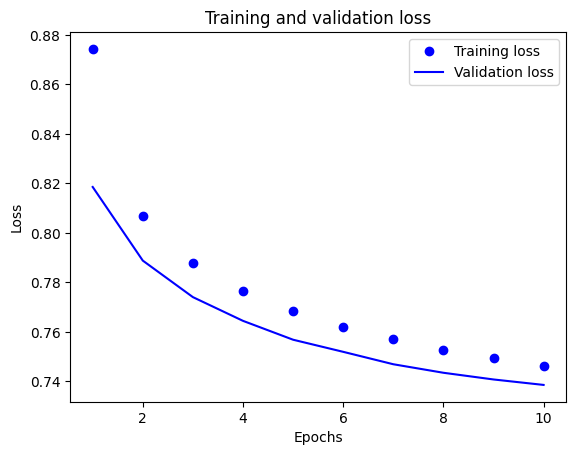

In [33]:
plot_loss_curves(history)

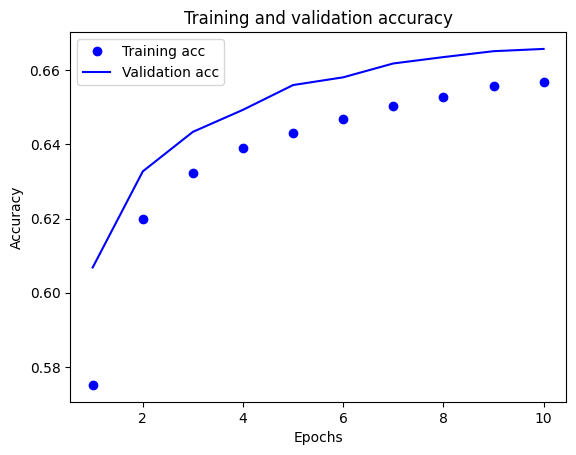

In [34]:
plot_acc_curves(history)

In [36]:
embedding_layer = keras.layers.Embedding(
    max_tokens,
    embedding_dim,
    embeddings_initializer=keras.initializers.Constant(embedding_matrix),
    trainable=True,
    mask_zero=True
)

input = keras.layers.Input(shape=(max_length,))
embedded = embedding_layer(input)
embedded = keras.layers.GlobalAveragePooling1D()(embedded)
x = keras.layers.Dense(32, activation='relu')(embedded)
x = keras.layers.Dropout(0.5)(x)
output = keras.layers.Dense(3, activation='softmax')(x)

model = keras.Model(input, output)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 300, 100)  │    300,000 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, 300)       │          0 │ input_layer_4[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ embedding_2[0][0… │
│ (GlobalAveragePool… │                   │            │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      3,232 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 3)         │         99 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 303,331 (1.16 MB)

 Trainable params: 303,331 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [38]:
history = model.fit(X_train,
          y_train,
          batch_size=32,
          epochs=10,
          validation_data=(X_val, y_val))

Epoch 1/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.6359 - loss: 0.7879 - val_accuracy: 0.6888 - val_loss: 0.6767
Epoch 2/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.6939 - loss: 0.6850 - val_accuracy: 0.7110 - val_loss: 0.6469
Epoch 3/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.7051 - loss: 0.6585 - val_accuracy: 0.7152 - val_loss: 0.6389
Epoch 4/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - accuracy: 0.7137 - loss: 0.6385 - val_accuracy: 0.7132 - val_loss: 0.6386
Epoch 5/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.7192 - loss: 0.6266 - val_accuracy: 0.7169 - val_loss: 0.6369
Epoch 6/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7258 - loss: 0.6152 - val_accuracy: 0.7175 - val_loss: 0.6390
Epoch 7/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - accuracy: 0.7310 - loss: 0.6065 - val_accuracy: 0.7169 - val_loss: 0.6426
Epoch 8/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7304 -

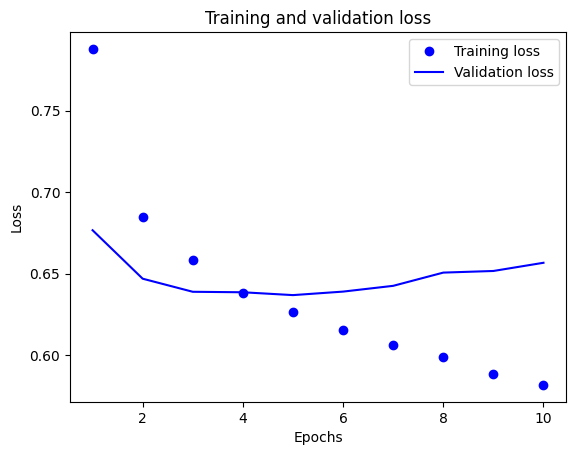

In [39]:
plot_loss_curves(history)

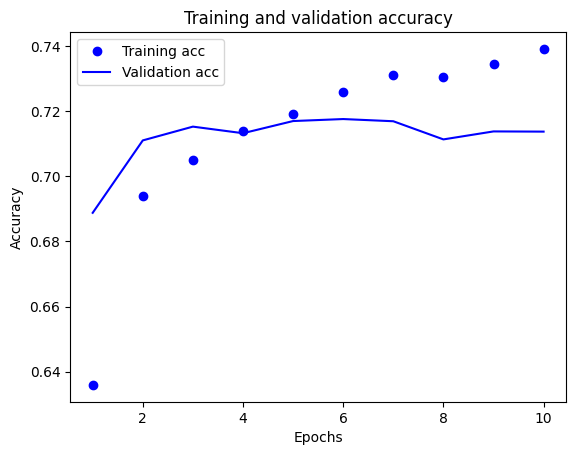

In [40]:
plot_acc_curves(history)

In [41]:
model.evaluate(X_test, y_test)

681/681 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7119 - loss: 0.6746


[0.6746339797973633, 0.7119041085243225]